In [ ]:
# ============================================================
# EXPERIMENT 1 - BASELINE PROJECT
# ============================================================

# load data
# preprocess data (fixing audio length)
# extract features using mfcc
# encode labels
# split data
# train with CNN + BiLSTM
# evaluate
# save model

In [ ]:
# Load audio

import os
import numpy as np
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

DATASET_PATH = "DataSet_Voice"

SAMPLE_RATE = 22050
DURATION = 3
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

N_MFCC = 40

LABELS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

In [44]:
# preprocess audio and extract mfcc

X = []
y = []

for label in LABELS:

    folder_path = os.path.join(DATASET_PATH, label)

    for file_name in os.listdir(folder_path):

        if file_name.endswith(".wav"):

            file_path = os.path.join(folder_path, file_name)

            try:
                # --------------------------------------------
                # LOAD AUDIO
                # --------------------------------------------

                signal, sr = librosa.load(
                    file_path,
                    sr=SAMPLE_RATE,
                    duration=DURATION
                )

                # --------------------------------------------
                # FIX AUDIO LENGTH
                # --------------------------------------------

                if len(signal) < SAMPLES_PER_TRACK:

                    padding = SAMPLES_PER_TRACK - len(signal)

                    signal = np.pad(
                        signal,
                        (0, padding),
                        mode='constant'
                    )

                else:
                    signal = signal[:SAMPLES_PER_TRACK]

                # --------------------------------------------
                # EXTRACT MFCC
                # --------------------------------------------

                mfcc = librosa.feature.mfcc(
                    y=signal,
                    sr=sr,
                    n_mfcc=N_MFCC
                )

                # --------------------------------------------
                # TRANSPOSE
                # --------------------------------------------

                mfcc = mfcc.T

                # --------------------------------------------
                # STORE
                # --------------------------------------------

                X.append(mfcc)
                y.append(label)

            except Exception as e:
                print(f"ERROR: {file_path}")
                print(e)

print(mfcc.shape)

(130, 40)


In [45]:
# encode labels

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

X shape: (11490, 130, 40)
y shape: (11490,)


In [46]:
# split train/val/test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.6,
    random_state=42,
    stratify=y_temp
)

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (8043, 130, 40, 1)
Validation shape: (1378, 130, 40, 1)
Test shape: (2069, 130, 40, 1)


In [47]:
# Train CNN

# COMPUTE CLASS WEIGHTS

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

# ONE-HOT ENCODE LABELS

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=7)
y_val = to_categorical(y_val, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

# BUILD CNN MODEL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Reshape,
    Bidirectional,
    LSTM,
    Dense
)

input_shape = X_train.shape[1:]

model = Sequential()

# ============================================================
# CNN BLOCK 1
# ============================================================

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=input_shape
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.3))

# ============================================================
# CNN BLOCK 2
# ============================================================

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.3))

# ============================================================
# CNN BLOCK 3
# ============================================================

model.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.3))

# ============================================================
# RESHAPE FOR LSTM
# ============================================================

model.add(Reshape((16, 640)))

# ============================================================
# BiLSTM
# ============================================================

model.add(Bidirectional(
    LSTM(
        128,
        return_sequences=False
    )
))

model.add(Dropout(0.4))

# ============================================================
# DENSE LAYER
# ============================================================

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.4))

# ============================================================
# OUTPUT LAYER
# ============================================================

model.add(Dense(
    7,
    activation='softmax'
))

# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# MODEL SUMMARY
# ============================================================

model.summary()

{0: 0.8811349693251533, 1: 0.8811349693251533, 2: 0.8811349693251533, 3: 0.8811349693251533, 4: 1.0370036101083033, 5: 0.8811349693251533, 6: 2.7686746987951807}


C:\Users\Acer\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 130, 40, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 130, 40, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 65, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 65, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 65, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 65, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 5, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16, 5, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 16, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 914,823 (3.49 MB)

 Trainable params: 914,375 (3.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [48]:
# Evaluate

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

Epoch 1/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.2510 - loss: 1.7769 - val_accuracy: 0.4478 - val_loss: 1.3358
Epoch 2/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.4536 - loss: 1.2554 - val_accuracy: 0.5573 - val_loss: 1.1138
Epoch 3/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.5089 - loss: 1.1173 - val_accuracy: 0.5537 - val_loss: 1.1035
Epoch 4/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.5292 - loss: 1.0895 - val_accuracy: 0.5522 - val_loss: 1.0848
Epoch 5/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.5606 - loss: 1.0237 - val_accuracy: 0.5776 - val_loss: 1.0602
Epoch 6/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.5594 - loss: 1.0166 - val_accuracy: 0.5929 - val_loss: 1.0539
Epoch 7/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.5816 - loss: 0.9842 - val_accuracy: 0.6147 - val_loss: 1.0076
Epoch 8/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.5767 - loss: 1.0018 - 

In [54]:
# Save model

model.save("voice_modelv1.h5")

print("Model saved as voice_modelv1.h5")

Model saved as voice_modelv1.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


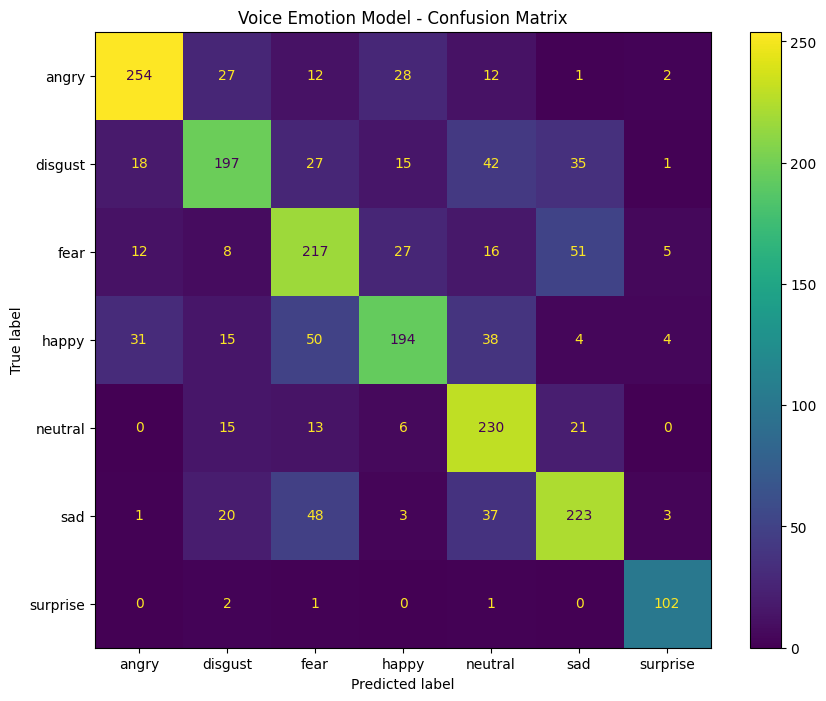

In [53]:
# Analysis to optimize the models

# ============================================================
# CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# PREDICT
# ============================================================

y_pred_probs = model.predict(X_test)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded labels back to integers
y_true = np.argmax(y_test, axis=1)

# ============================================================
# LABELS
# ============================================================

labels = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

# ============================================================
# DISPLAY
# ============================================================

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax)

plt.title("Voice Emotion Model - Confusion Matrix")

plt.show()

from the above matrix, we can see that the model is confused between some emotions:

1. fear and sad
    - lower pitch variation
    - tense tone
    - similar spectral patterns
    MFCC couldnt properly seperate
2. happy as fear (big issue)
    - speaker variation
    - exaggerated emotional acting
    - dataset inconsistency (4 different datasets)
3. disgust as neutral
    - MFCC couldnt properly extract features

surprise did surprisingly well

CNN architecture working well, was able to classify. Problem is with feature extraction.

In [ ]:
# ============================================================
# EXPERIMENT 2 - DELTA MFCC FEATURES
# ============================================================

# extract features using MFCC + Delta + Delta-Delta
# encode labels
# split data
# train with CNN + BiLSTM
# evaluate
# save model

In [70]:
X_v2 = []
y_v2 = []

for label in LABELS:

    folder_path = os.path.join(DATASET_PATH, label)

    for file_name in os.listdir(folder_path):

        if file_name.endswith(".wav"):

            file_path = os.path.join(folder_path, file_name)

            try:

                # ------------------------------------------------
                # LOAD AUDIO
                # ------------------------------------------------

                signal, sr = librosa.load(
                    file_path,
                    sr=SAMPLE_RATE,
                    duration=DURATION
                )

                # ------------------------------------------------
                # FIX LENGTH
                # ------------------------------------------------

                if len(signal) < SAMPLES_PER_TRACK:

                    padding = SAMPLES_PER_TRACK - len(signal)

                    signal = np.pad(
                        signal,
                        (0, padding),
                        mode='constant'
                    )

                else:
                    signal = signal[:SAMPLES_PER_TRACK]

                # ------------------------------------------------
                # MFCC
                # ------------------------------------------------

                mfcc = librosa.feature.mfcc(
                    y=signal,
                    sr=sr,
                    n_mfcc=N_MFCC
                )

                # ------------------------------------------------
                # DELTA MFCC
                # ------------------------------------------------

                delta_mfcc = librosa.feature.delta(mfcc)

                # ------------------------------------------------
                # DELTA-DELTA MFCC
                # ------------------------------------------------

                delta2_mfcc = librosa.feature.delta(
                    mfcc,
                    order=2
                )

                # ------------------------------------------------
                # STACK FEATURES
                # ------------------------------------------------

                combined = np.vstack([
                    mfcc,
                    delta_mfcc,
                    delta2_mfcc
                ])

                # ------------------------------------------------
                # TRANSPOSE
                # ------------------------------------------------

                combined = combined.T

                X_v2.append(combined)
                y_v2.append(label)

            except Exception as e:

                print(f"ERROR: {file_path}")
                print(e)

# ============================================================
# NUMPY
# ============================================================

X_v2 = np.array(X_v2)
y_v2 = np.array(y_v2)

print("X_v2 shape:", X_v2.shape)
print("y_v2 shape:", y_v2.shape)

X_v2 shape: (11490, 130, 120)
y_v2 shape: (11490,)


In [71]:
# encode labels

X_v2 = np.array(X_v2)
y_v2 = np.array(y_v2)

print("X_v2 shape:", X_v2.shape)
print("y_v2 shape:", y_v2.shape)

label_encoder = LabelEncoder()

y_encoded_v2 = label_encoder.fit_transform(y_v2)

X_v2 shape: (11490, 130, 120)
y_v2 shape: (11490,)


In [72]:
# split train/val/test

X_train_v2, X_temp_v2, y_train_v2, y_temp_v2 = train_test_split(
    X_v2,
    y_encoded_v2,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded_v2
)

X_val_v2, X_test_v2, y_val_v2, y_test_v2 = train_test_split(
    X_temp_v2,
    y_temp_v2,
    test_size=0.6,
    random_state=42,
    stratify=y_temp_v2
)

X_train_v2 = X_train_v2[..., np.newaxis]
X_val_v2 = X_val_v2[..., np.newaxis]
X_test_v2 = X_test_v2[..., np.newaxis]

print("Train shape:", X_train_v2.shape)
print("Validation shape:", X_val_v2.shape)
print("Test shape:", X_test_v2.shape)

Train shape: (8043, 130, 120, 1)
Validation shape: (1378, 130, 120, 1)
Test shape: (2069, 130, 120, 1)


In [73]:
# ============================================================
# EXPERIMENT 2 MODEL
# CNN + BiLSTM
# MFCC + DELTA + DELTA-DELTA
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Reshape,
    Bidirectional,
    LSTM,
    Dense
)

input_shape_v2 = X_train_v2.shape[1:]

model_v2 = Sequential()

# ============================================================
# CNN BLOCK 1
# ============================================================

model_v2.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=input_shape_v2
))

model_v2.add(BatchNormalization())

model_v2.add(MaxPooling2D((2,2)))

model_v2.add(Dropout(0.3))

# ============================================================
# CNN BLOCK 2
# ============================================================

model_v2.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model_v2.add(BatchNormalization())

model_v2.add(MaxPooling2D((2,2)))

model_v2.add(Dropout(0.3))

# ============================================================
# CNN BLOCK 3
# ============================================================

model_v2.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))

model_v2.add(BatchNormalization())

model_v2.add(MaxPooling2D((2,2)))

model_v2.add(Dropout(0.3))

# ============================================================
# RESHAPE FOR LSTM
# ============================================================

model_v2.add(Reshape((16, 1920)))

# ============================================================
# BiLSTM
# ============================================================

model_v2.add(Bidirectional(
    LSTM(
        128,
        return_sequences=False
    )
))

model_v2.add(Dropout(0.4))

# ============================================================
# DENSE LAYER
# ============================================================

model_v2.add(Dense(
    128,
    activation='relu'
))

model_v2.add(Dropout(0.4))

# ============================================================
# OUTPUT LAYER
# ============================================================

model_v2.add(Dense(
    7,
    activation='softmax'
))

# ============================================================
# COMPILE
# ============================================================

model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# SUMMARY
# ============================================================

model_v2.summary()

C:\Users\Acer\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 130, 120, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 130, 120, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 65, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 65, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 65, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 65, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 32, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 16, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 16, 1920)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,225,543 (8.49 MB)

 Trainable params: 2,225,095 (8.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [74]:
# ============================================================
# SAVE INTEGER LABELS
# ============================================================

y_train_v2_int = y_train_v2.copy()
y_val_v2_int = y_val_v2.copy()
y_test_v2_int = y_test_v2.copy()

# ============================================================
# CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

class_weights_v2 = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_v2_int),
    y=y_train_v2_int
)

class_weights_v2 = dict(enumerate(class_weights_v2))

print(class_weights_v2)

# ============================================================
# ONE-HOT ENCODING
# ============================================================

from tensorflow.keras.utils import to_categorical

y_train_v2 = to_categorical(y_train_v2_int, num_classes=7)

y_val_v2 = to_categorical(y_val_v2_int, num_classes=7)

y_test_v2 = to_categorical(y_test_v2_int, num_classes=7)

# ============================================================
# TRAIN
# ============================================================

history_v2 = model_v2.fit(
    X_train_v2,
    y_train_v2,
    validation_data=(X_val_v2, y_val_v2),
    epochs=40,
    batch_size=32,
    class_weight=class_weights_v2
)

# ============================================================
# EVALUATE
# ============================================================

test_loss_v2, test_accuracy_v2 = model_v2.evaluate(
    X_test_v2,
    y_test_v2
)

print("Test Accuracy:", test_accuracy_v2)

{0: 0.8811349693251533, 1: 0.8811349693251533, 2: 0.8811349693251533, 3: 0.8811349693251533, 4: 1.0370036101083033, 5: 0.8811349693251533, 6: 2.7686746987951807}
Epoch 1/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 43s 161ms/step - accuracy: 0.1857 - loss: 1.9150 - val_accuracy: 0.3875 - val_loss: 1.5407
Epoch 2/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.3705 - loss: 1.4629 - val_accuracy: 0.4855 - val_loss: 1.2681
Epoch 3/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.4416 - loss: 1.2668 - val_accuracy: 0.5493 - val_loss: 1.1665
Epoch 4/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.5030 - loss: 1.1486 - val_accuracy: 0.5581 - val_loss: 1.1485
Epoch 5/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 44s 173ms/step - accuracy: 0.5027 - loss: 1.1306 - val_accuracy: 0.5806 - val_loss: 1.0767
Epoch 6/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.5265 - loss: 1.0928 - val_accuracy: 0.5784 - val_loss: 1.0850
Epoch 7/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 41s 164ms/st

In [75]:
# Save model

# model.save("voice_modelv2.h5")

# print("Model saved as voice_modelv2.h5")

In [76]:
# ============================================================
# EXPERIMENT 3 - SILENCE REMOVAL
# ============================================================

In [77]:
# Save model

# model.save("voice_modelv3.h5")

# print("Model saved as voice_modelv3.h5")